In [2]:
import matplotlib.pyplot as plt
import os

FIGURE_FOLDER = 'figures/'
RESULTS_FOLDER = 'results/'

if not os.path.exists(FIGURE_FOLDER): os.mkdir(FIGURE_FOLDER)

In [7]:
def plot_compare_smas(sma_range: list[int], offset_range: list[int] = None, file_str: str = 'mse-{0}-{1}-results.csv', title_prefix: str = "", save: bool = False):    
    if offset_range == None:
        offset_range = sma_range

    xs = offset_range
    colors = ['pink','red','orange','green','blue','grey']

    titles = [
        "Very Close Percentage for SMAs",
        "Close Percentage for SMAs",
        "Moderate Percentage for SMAs",
        "Far Percentage for SMAs",
        "Validation R^2 for SMAs",
        "Total R^2 for SMAs",
        "Percentage Difference for SMAs"
    ]

    y_labels = [
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "Multiplier Better Than Mean",
        "R^2 Score",
        "R^2 Score",
        "% Difference"
    ]

    data = []

    for _ in titles:
        data.append([])

    for window in sma_range:
        for i in range(len(data)):
            data[i].append([])

        for offset in offset_range:
            with open(RESULTS_FOLDER + file_str.format(window, offset)) as f:
                f.readline()
                
                cur_data = list(map(float, f.readline().split(',')))

                for i in range(len(cur_data)):
                    data[i][-1].append(cur_data[i])

    for i in range(len(titles)):
        plt.title(title_prefix + titles[i])

        for j in range(len(sma_range)):
            plt.plot(xs, data[i][j], label=f"SMA:{sma_range[j]}", color=colors[j], marker='o')

        plt.xlabel("Offset")
        plt.ylabel(y_labels[i])
        plt.legend()

        #if save: 
        #    plt.savefig(FIGURE_FOLDER + file_title + '-mae.png')
        #    plt.close()
        #else: plt.show()

        plt.show()

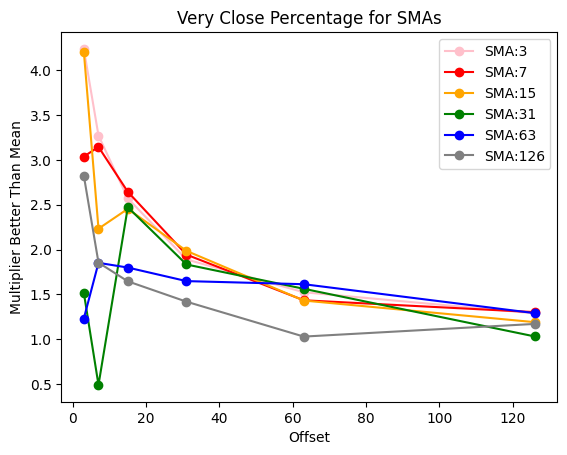

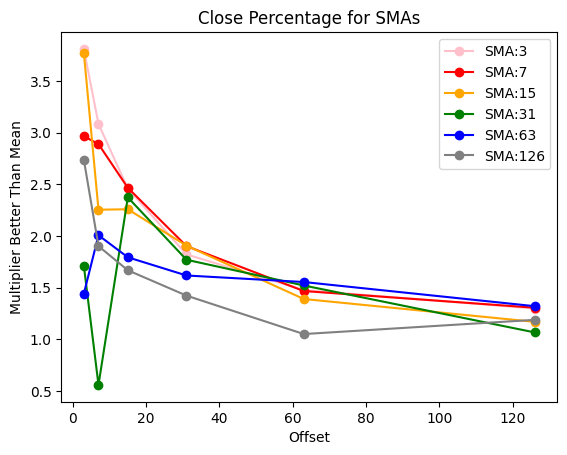

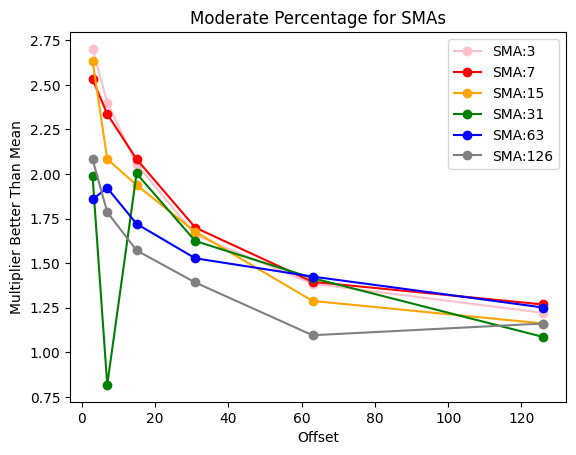

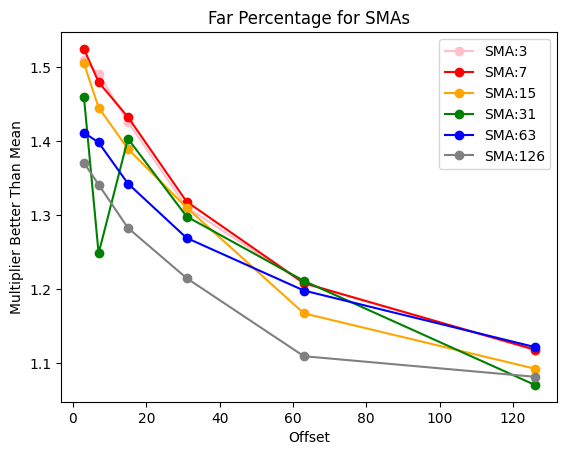

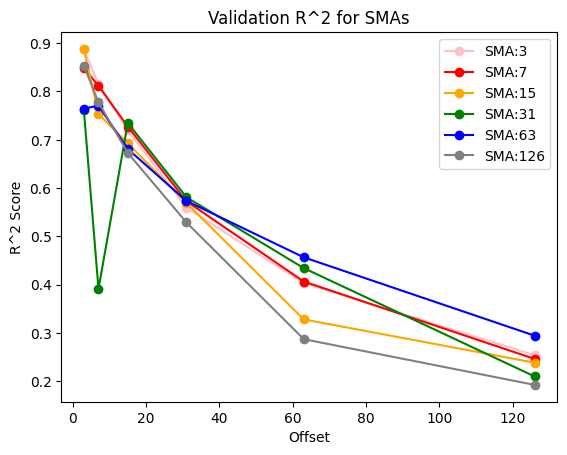

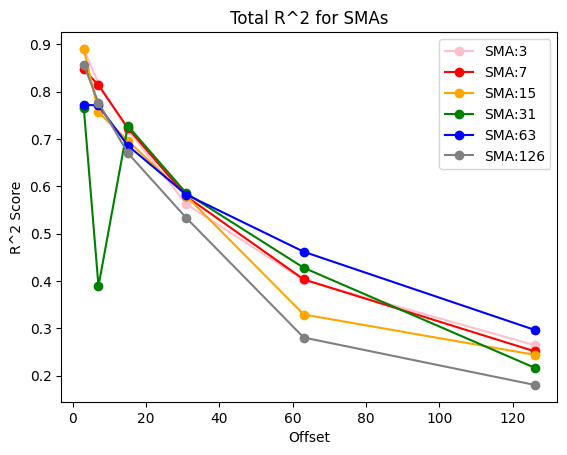

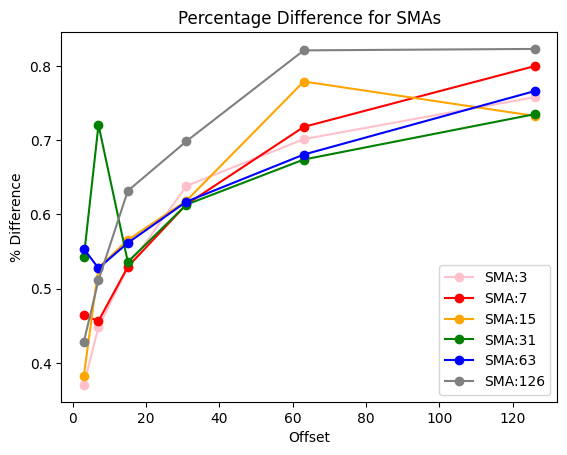

In [8]:
plot_compare_smas([3,7,15,31,63,126])

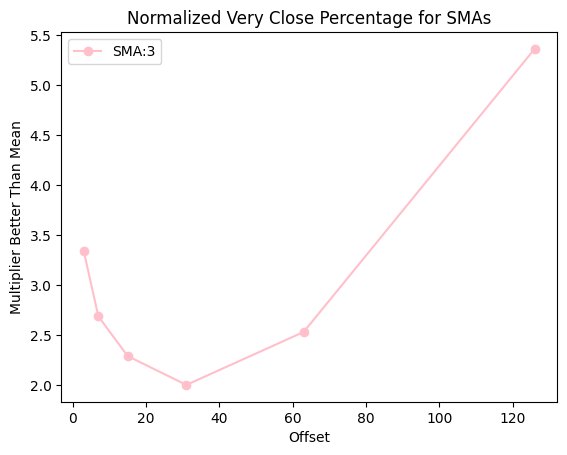

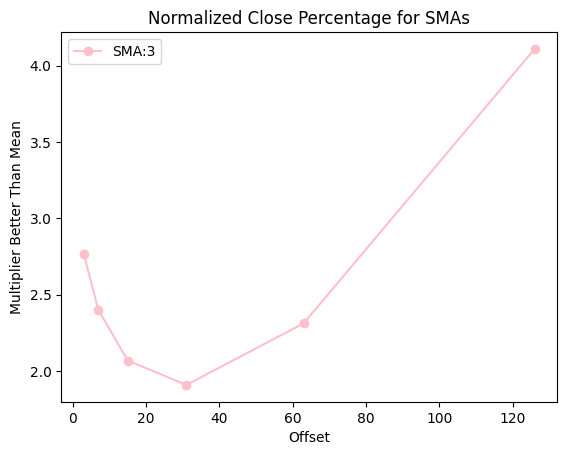

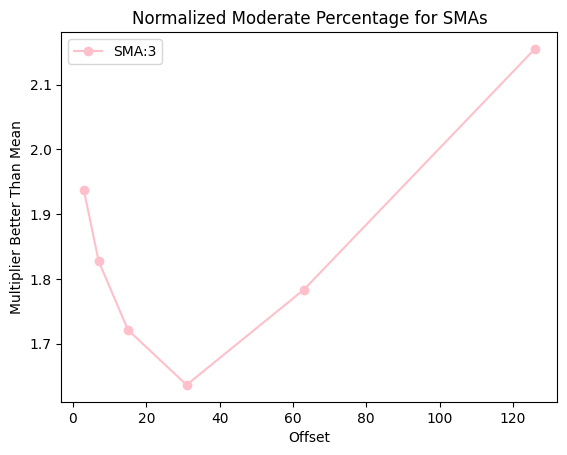

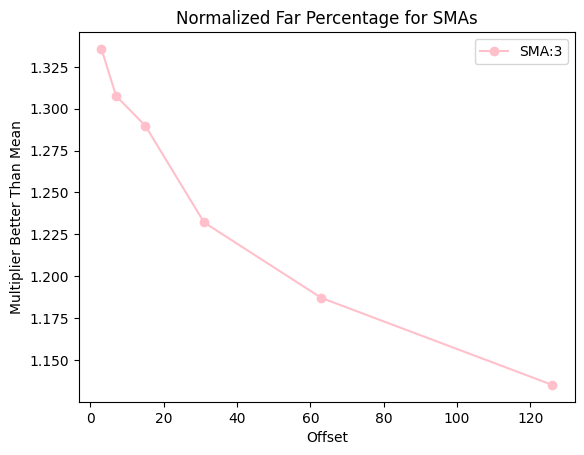

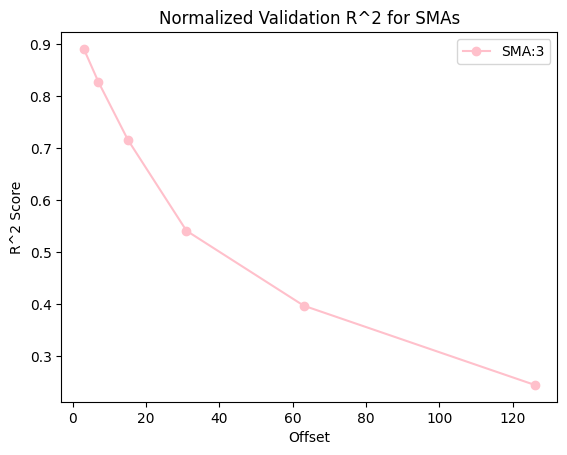

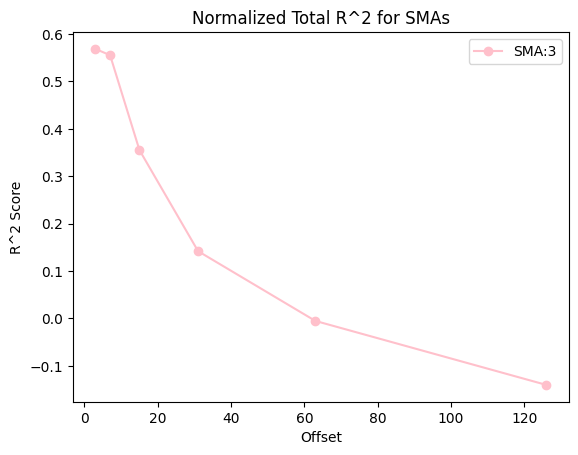

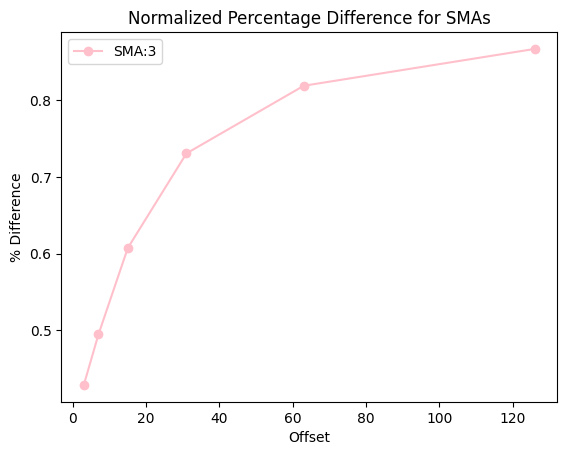

In [6]:
plot_compare_smas([3], [3,7,15,31,63,126], 'normalized-mse-{0}-{1}-results.csv', title_prefix='Normalized ')